In [2]:
import plotly.graph_objects as go
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import numpy as np

In [3]:
ticker = "MSTR"
start_date = "2025-01-01"
end_date = "2026-06-13"

df = yf.download(ticker, start=start_date, end=end_date)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.to_csv("Stock.csv")

C:\Users\cjdan\AppData\Local\Temp\ipykernel_22292\3440246803.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [4]:
# --- Define Split Ratio ---
train_ratio = 0.8  # 80% for training, 20% for testing
total_days = len(df)
split_idx = int(total_days * train_ratio)

# --- Split the Data Chronologically ---
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print(f"Total Rows: {total_days}")
print(f"Training Rows (First 80%): {len(train_df)} (From {train_df.index[0].date()} to {train_df.index[-1].date()})")
print(f"Testing Rows (Last 20%): {len(test_df)} (From {test_df.index[0].date()} to {test_df.index[-1].date()})")

# --- Extract Features Separately ---
train_features = train_df[['Open', 'Close']].to_numpy()
test_features = test_df[['Open', 'Close']].to_numpy()

Total Rows: 362
Training Rows (First 80%): 289 (From 2025-01-02 to 2026-02-27)
Testing Rows (Last 20%): 73 (From 2026-03-02 to 2026-06-12)


In [5]:
# 1. Fit the scaler on TRAINING data only
train_min = train_features.min(axis=0)
train_max = train_features.max(axis=0)

# 2. Scale the training windows
T = train_features.shape[0]
window_data_train = train_features[0:T, :]
scaled_window_train = (window_data_train - train_min) / (train_max - train_min)
batch_size = 50

train_batches = []

for start in range(T - batch_size):
    batch = scaled_window_train[start:start + batch_size]
    train_batches.append(batch.T)
    
# 3. Scale the testing windows using TRAINING parameters
T_test = test_features.shape[0]
window_data_test = test_features[0:T_test, :]
scaled_window_test = (window_data_test - train_min) / (train_max - train_min)
inputVar_test = scaled_window_test.T  # Shape: (2, T_test)

In [6]:
input_size = 2     
hidden_size = 8   
output_size = 2    

WxH = np.random.randn(hidden_size, input_size) * np.sqrt(1 / input_size)
WhH = np.random.randn(hidden_size, hidden_size) * np.sqrt(1 / hidden_size)
WhY = np.random.randn(output_size, hidden_size) * np.sqrt(1 / hidden_size)

biasWV = np.zeros((hidden_size, 1))
biasWY = np.zeros((output_size, 1))
hS0_train = np.zeros((hidden_size, 1))
hS0_test = np.zeros((hidden_size, 1))

In [7]:
def tanh(x):
    x = np.clip(x, -30, 30)
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

Epoch    0 | MSE Loss: 0.010352
Epoch   20 | MSE Loss: 0.009461
Epoch   40 | MSE Loss: 0.009218
Epoch   60 | MSE Loss: 0.009102
Epoch   80 | MSE Loss: 0.009031
Epoch  100 | MSE Loss: 0.008981
Epoch  120 | MSE Loss: 0.008944
Epoch  140 | MSE Loss: 0.008916
Epoch  160 | MSE Loss: 0.008892
Epoch  180 | MSE Loss: 0.008873
Epoch  200 | MSE Loss: 0.008856
Epoch  220 | MSE Loss: 0.008842
Epoch  240 | MSE Loss: 0.008829
Epoch  260 | MSE Loss: 0.008818
Epoch  280 | MSE Loss: 0.008807
Epoch  299 | MSE Loss: 0.008798


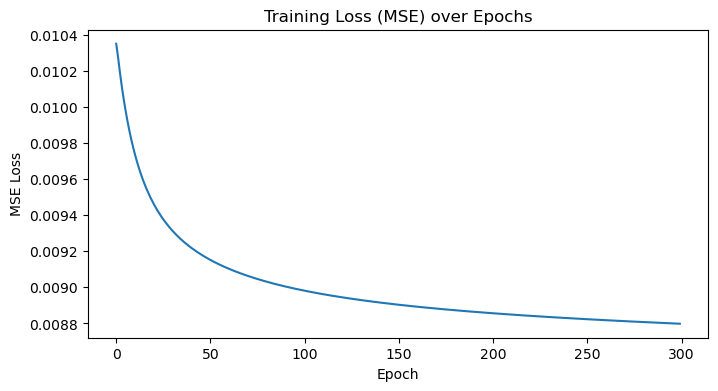

Predicted next-day (Open, Close) after training window: [112.39898375 116.03990742]


In [10]:
num_epochs = 300
learning_rate = 0.001
clip_value = 5.0
loss_history = []

for epoch in range(num_epochs):
    #Forward pass
    epoch_loss = 0

    for inputVar_train in train_batches:

        T = inputVar_train.shape[1]

        hidden_states_train = []
        outputs_train = []
        hS_current = hS0_train.copy()

        for t in range(T):
            xt = inputVar_train[:, t].reshape(2, 1)
            hState_train = tanh(np.dot(WxH, xt) + np.dot(WhH, hS_current) + biasWV)
            outputVal_train = np.dot(WhY, hState_train) + biasWY

            hidden_states_train.append(hState_train)
            outputs_train.append(outputVal_train)
            hS_current = hState_train

        targets_train = [inputVar_train[:, t + 1].reshape(2, 1) for t in range(T - 1)]

        #BPTT
        dLdWxh = np.zeros_like(WxH)
        dLdWhh = np.zeros_like(WhH)
        dLdWhy = np.zeros_like(WhY)
        dLdbWV = np.zeros_like(biasWV)
        dLdbWY = np.zeros_like(biasWY)

        hiddenStateLossAccumulator_next = np.zeros((hidden_size, 1))
        batch_loss = 0.0

        for t in reversed(range(T - 1)):
            dLossdyt = 2 * (outputs_train[t] - targets_train[t])
            batch_loss += np.sum((outputs_train[t] - targets_train[t]) ** 2)

            hiddenStateLossAccumulatorStep1 = (
                np.dot(WhY.T, dLossdyt) + np.dot(WhH.T, hiddenStateLossAccumulator_next)
            )
            hiddenStateLossAccumulatorStep2 = 1 - (hidden_states_train[t] ** 2)
            hiddenStateLossAccumulator = (
                hiddenStateLossAccumulatorStep1 * hiddenStateLossAccumulatorStep2
            )

            xt = inputVar_train[:, t].reshape(2, 1)
            dLdWxh += np.dot(hiddenStateLossAccumulator, xt.T)

            prev_h = hidden_states_train[t - 1] if t > 0 else hS0_train
            dLdWhh += np.dot(hiddenStateLossAccumulator, prev_h.T)

            dLdWhy += np.dot(dLossdyt, hidden_states_train[t].T)

            dLdbWV += hiddenStateLossAccumulator
            dLdbWY += dLossdyt
            hiddenStateLossAccumulator_next = hiddenStateLossAccumulator

        #Gradient clipping
        for grad in (dLdWxh, dLdWhh, dLdWhy, dLdbWV, dLdbWY):
            np.clip(grad, -clip_value, clip_value, out=grad)

        #Weight update
        WhY -= learning_rate * dLdWhy
        WhH -= learning_rate * dLdWhh
        WxH -= learning_rate * dLdWxh
        biasWV -= learning_rate * dLdbWV
        biasWY -= learning_rate * dLdbWY

        epoch_loss += batch_loss / (T - 1)

    loss_history.append(epoch_loss / (T - 1))

    if epoch % 20 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:4d} | MSE Loss: {loss_history[-1]:.6f}")

#Plot the loss curve to confirm the model is actually learning
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss (MSE) over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

#Final prediction for the day after the training window
tomorrow_hidden_train = tanh(np.dot(WhH, hS_current) + biasWV)
pred_scaled_train = np.dot(WhY, tomorrow_hidden_train) + biasWY
pred_unscaled_train = pred_scaled_train.flatten() * (train_max - train_min) + train_min

print(f"Predicted next-day (Open, Close) after training window: {pred_unscaled_train}")

In [22]:
for t in range(T_test):
    xt = inputVar_test[:, t].reshape(2, 1)
    hState_test = tanh(np.dot(WxH, xt) + np.dot(WhH, hS0_test) + biasWV)
    outputVal_test = np.dot(WhY, hState_test) + biasWY
    hS0_test = hState_test

# Final Prediction for next step after testing window
tomorrow_hidden_test = tanh(np.dot(WhH, hS0_test) + biasWV)
pred_scaled_test = np.dot(WhY, tomorrow_hidden_test) + biasWY
pred_unscaled_test = pred_scaled_test.flatten() * (train_max - train_min) + train_min
print(f"Prediction right after Test Window: {pred_unscaled_test}")

Prediction right after Test Window: [109.77234088 112.92639721]
